In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from dotenv import load_dotenv

In [ ]:
load_dotenv("../.env")
data_path = os.getenv("filtered_paraquet_path")

In [3]:
df= pd.read_parquet(data_path)

In [4]:
df["year"].between(2008, 2016).value_counts()

year
True     1119460
False     225890
Name: count, dtype: int64

In [5]:
train = df[df["year"].between(2008, 2016)].copy()
test  = df[df["year"].between(2017, 2018)].copy()

In [6]:
train.head()

,id,loan_amnt,term,int_rate,grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,...,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,target,year
0,68407277,3600.0,36 months,13.99,C,10+ years,MORTGAGE,55000.0,Not Verified,2015-12-01,...,0.0,Aug-2003,1.0,7.0,0.0,2765.0,29.7,13.0,0,2015
1,68355089,24700.0,36 months,11.99,C,10+ years,MORTGAGE,65000.0,Not Verified,2015-12-01,...,1.0,Dec-1999,4.0,22.0,0.0,21470.0,19.2,38.0,0,2015
2,68341763,20000.0,60 months,10.78,B,10+ years,MORTGAGE,63000.0,Not Verified,2015-12-01,...,0.0,Aug-2000,0.0,6.0,0.0,7869.0,56.2,18.0,0,2015
3,68476807,10400.0,60 months,22.45,F,3 years,MORTGAGE,104433.0,Source Verified,2015-12-01,...,1.0,Jun-1998,3.0,12.0,0.0,21929.0,64.5,35.0,0,2015
4,68426831,11950.0,36 months,13.44,C,4 years,RENT,34000.0,Source Verified,2015-12-01,...,0.0,Oct-1987,0.0,5.0,0.0,8822.0,68.4,6.0,0,2015


In [23]:
df["verification_status"].value_counts()

verification_status
Source Verified    521289
Verified           418352
Not Verified       405709
Name: count, dtype: int64

In [7]:
train.columns

Index(['id', 'loan_amnt', 'term', 'int_rate', 'grade', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'issue_d',
       'loan_status', 'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc', 'target', 'year'],
      dtype='object')

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1119460 entries, 0 to 1345349
Data columns (total 23 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   id                   1119460 non-null  object        
 1   loan_amnt            1119460 non-null  float64       
 2   term                 1119460 non-null  object        
 3   int_rate             1119460 non-null  float64       
 4   grade                1119460 non-null  object        
 5   emp_length           1058003 non-null  object        
 6   home_ownership       1119460 non-null  object        
 7   annual_inc           1119460 non-null  float64       
 8   verification_status  1119460 non-null  object        
 9   issue_d              1119460 non-null  datetime64[us]
 10  loan_status          1119460 non-null  object        
 11  purpose              1119460 non-null  object        
 12  dti                  1119420 non-null  float64       
 13  de

In [9]:
train.describe()

,loan_amnt,int_rate,annual_inc,issue_d,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,target,year
count,1.119460e+06,1.119460e+06,1.119460e+06,1119460,1.119420e+06,1.119460e+06,1.119459e+06,1.119460e+06,1.119460e+06,1.119460e+06,1.118828e+06,1.119460e+06,1.119460e+06,1.119460e+06
mean,1.441598e+04,1.312814e+01,7.564690e+04,2014-12-25 23:32:01.950940,1.818891e+01,3.216399e-01,6.707410e-01,1.159394e+01,2.143489e-01,1.647507e+04,5.333939e+01,2.514335e+01,1.969798e-01,2.014514e+03
min,5.000000e+02,5.320000e+00,0.000000e+00,2008-01-01 00:00:00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.008000e+03
25%,8.000000e+03,9.670000e+00,4.500000e+04,2014-04-01 00:00:00,1.188000e+01,0.000000e+00,0.000000e+00,8.000000e+00,0.000000e+00,6.151000e+03,3.550000e+01,1.600000e+01,0.000000e+00,2.014000e+03
50%,1.200000e+04,1.274000e+01,6.500000e+04,2015-05-01 00:00:00,1.765000e+01,0.000000e+00,0.000000e+00,1.100000e+01,0.000000e+00,1.137000e+04,5.390000e+01,2.300000e+01,0.000000e+00,2.015000e+03
75%,2.000000e+04,1.580000e+01,9.000000e+04,2016-01-01 00:00:00,2.402000e+01,0.000000e+00,1.000000e+00,1.400000e+01,0.000000e+00,2.005900e+04,7.190000e+01,3.200000e+01,0.000000e+00,2.016000e+03
max,4.000000e+04,3.099000e+01,9.550000e+06,2016-12-01 00:00:00,9.990000e+02,3.900000e+01,8.000000e+00,9.000000e+01,8.600000e+01,2.904836e+06,8.923000e+02,1.760000e+02,1.000000e+00,2.016000e+03
std,8.520102e+03,4.576225e+00,6.833941e+04,NaN,9.020841e+00,8.800260e-01,9.542243e-01,5.408202e+00,6.104803e-01,2.237127e+04,2.408210e+01,1.192699e+01,3.977171e-01,1.387169e+00


In [10]:
train.isnull().sum()

id                         0
loan_amnt                  0
term                       0
int_rate                   0
grade                      0
emp_length             61457
home_ownership             0
annual_inc                 0
verification_status        0
issue_d                    0
loan_status                0
purpose                    0
dti                       40
delinq_2yrs                0
earliest_cr_line           0
inq_last_6mths             1
open_acc                   0
pub_rec                    0
revol_bal                  0
revol_util               632
total_acc                  0
target                     0
year                       0
dtype: int64

In [ ]:
train.duplicated().sum()

np.int64(0)

In [12]:
train["target"].value_counts()

target
0    898949
1    220511
Name: count, dtype: int64

In [19]:
def clean(d):
    d = d.copy()
    d["term"] = d["term"].str.extract(r"(\d+)")[0].astype(int)
    d["emp_length"] = (d["emp_length"].str.replace("< 1 year", "0", regex=False).str.extract(r"(\d+)")[0].astype(float))
    d["earliest_cr_line"] = pd.to_datetime(d["earliest_cr_line"], format="%b-%Y")
    d["credit_hist_years"] = (d["issue_d"] - d["earliest_cr_line"]).dt.days / 365
    return d

train = clean(train)
test = clean(test)

In [ ]:
def clean_cats(d):
    d = d.copy()
    d["home_ownership"] = d["home_ownership"].replace(
        {"ANY": "OTHER", "NONE": "OTHER"})
    d["purpose"] = d["purpose"].replace({"renewable_energy": "other","educational": "other"})
    d["verification_status"]= d["verification_status"].replace({"Source Verified": "Verified"})
    return d

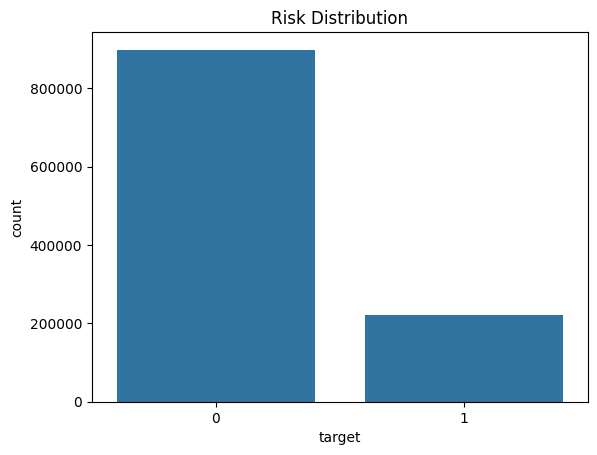

In [13]:
sns.countplot(data=train, x='target')
plt.title("Risk Distribution")
plt.show()

In [ ]:
fig, axes = plt.subplots(3,3, figsize=(22, 16))
sns.set_theme(style="white",font_scale=1.8)

axes[0,0].set_title('Risk Distribution by Loan Amt')
sns.countplot(data=train, x='loan_amnt', hue='target', ax=axes[0,0])
axes[0,1].set_title('Risk Distribution by Term')
sns.countplot(data=train, x='term', hue='target', ax=axes[0,1])
axes[0,2].set_title('Risk Distribution by Emp length')
sns.countplot(data=train, x='emp_length', hue='target', ax=axes[0,2])
axes[1,0].set_title('Risk Distribution by Home Ownership')
sns.countplot(data=train, x='home_ownership', hue='target', ax=axes[1,0])
axes[1,1].set_title('Risk Distribution by Phone Service')
sns.countplot(data=train, x='PhoneService', hue='target', ax=axes[1,1])
axes[1,2].set_title('Risk Distribution by Internet Service')
sns.countplot(data=train, x='InternetService', hue='target', ax=axes[1,2])
axes[2,0].set_title('Risk Distribution by Contract')
sns.countplot(data=train, x='Contract', hue='target', ax=axes[2,0])
axes[2,1].set_title('Risk Distribution by Paperless Billing')
sns.countplot(data=train, x='PaperlessBilling', hue='target', ax=axes[2,1])
axes[2,2].set_title('Risk Distribution by Payment Method')
sns.countplot(data=train, x='PaymentMethod', hue='target', ax=axes[2,2])
sns.move_legend(axes[2,0], "upper right")
axes[2,2].set_xticklabels(axes[2,2].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()